### Análisis de la temperatura

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx

from RRAM import Representate as rp
from RRAM.Representate import config_ax, setup_paper_plt, config_ax_state
from RRAM.Representate import RepresentateState

from pathlib import Path


In [2]:
def plot_temperature_profile(
    T_matrix: np.ndarray,
    atom_size: float,
    columna_x: int,
    step: int = 4,
    title: str = "Vertical Temperature Profile",
    save_path: str | None = None,
    usar_latex: bool = True,
    scaling: float = 2.5,
):
    """
    Genera un gráfico 2D del perfil de caída de temperatura vertical,
    empleando la configuración global de estilo para publicación.
    """
    # 1. Aplicar los estilos globales ANTES de crear la figura
    setup_paper_plt(plt, latex=usar_latex, scaling=scaling)

    # 2. Extraer los datos verticalmente (fijamos X, recorremos Y)
    data_y = T_matrix[:, columna_x]

    # 3. Calcular el vector de distancias físicas en nm (Eje X del plot)
    distancias = np.arange(0, T_matrix.shape[0]) * atom_size

    # 4. Crear la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 9))

    # 5. Aplicar la configuración de estilo específica para los ejes (Grid, ticks, etc.)
    config_ax(ax)

    # 6. Dibujar la línea continua con puntos espaciados según 'step'
    ax.plot(
        distancias,
        data_y,
        color="#1976D2",  # Azul técnico
        linewidth=2.5,
        label=f"Posición X = {columna_x}",
        marker="o",
        markersize=6 * (scaling / 2.5),  # Escala el punto con el tamaño global
        markevery=step,
        markerfacecolor="white",
        markeredgewidth=1.5,
    )

    # 7. Configurar etiquetas y estética usando comandos de siunitx
    ax.set_xlabel(r"Vertical Distance (\si{\nano\meter})")
    ax.set_ylabel(r"Temperature (K)")
    ax.set_title(title, pad=15)

    ax.legend(loc="upper right")

    plt.tight_layout()

    # 5. Guardar la gráfica
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

        # Opcional: guardar en pdf también
        # ruta_pdf = os.path.splitext(save_path)[0] + ".pdf"
        # plt.savefig(ruta_pdf, bbox_inches="tight")

    plt.close(fig)

    return None

In [3]:
def extraer_perfiles_pendiente_temperatura(
    lista_matrices: list,
    etiquetas: list,
    columna_x: int,
    atom_size: float,
    distancia_separacion: float = 1.0,  # Separación en nm para la pendiente
):
    """
    Extrae el perfil vertical de temperatura, submuestrea según la distancia
    especificada (ej. 1 nm) y calcula la pendiente (dT/dx) entre esos puntos.
    """
    if len(lista_matrices) != len(etiquetas):
        raise ValueError("Debe haber el mismo número de matrices que de etiquetas.")

    # 1. Calcular cuántos índices de la matriz equivalen a "1 nm"
    paso_idx = int(round(distancia_separacion / atom_size))
    if paso_idx < 1:
        paso_idx = 1  # Evita errores si se pide menos de 1 celda

    # 2. Vector de distancias originales
    distancias_orig = np.arange(0, lista_matrices[0].shape[0]) * atom_size

    # 3. Vector de distancias submuestreado (puntos cada 1 nm)
    distancias_sub = distancias_orig[::paso_idx]

    # 4. El eje X de la gráfica será el PUNTO MEDIO entre los dos puntos evaluados
    # (Físicamente la derivada entre x1 y x2 representa la pendiente en el medio)
    distancias_plot = distancias_sub[:-1] + (np.diff(distancias_sub) / 2)

    perfiles_pendientes = {}

    for matriz, etiqueta in zip(lista_matrices, etiquetas):
        # Extraemos solo la columna deseada
        perfil_orig = matriz[:, columna_x]

        # Tomamos valores de temperatura cada 1 nm
        perfil_sub = perfil_orig[::paso_idx]

        # Calculamos la pendiente: Delta T / Delta X
        # np.diff(perfil_sub) hace: T_siguiente - T_actual
        pendiente = np.diff(perfil_sub) / np.diff(distancias_sub)

        perfiles_pendientes[etiqueta] = pendiente

    return distancias_plot, perfiles_pendientes


In [4]:
def extraer_perfiles_temperatura(lista_matrices: list, etiquetas: list, columna_x: int, atom_size: float):
    """
    Extrae el perfil vertical de temperatura para múltiples matrices.

    Argumentos:
    - lista_matrices: Lista de arrays 2D de temperatura.
    - etiquetas: Nombres para la leyenda (ej: ["1.0 V", "1.5 V", "2.0 V"]).
    - columna_x: Índice de la columna a evaluar.
    - atom_size: Tamaño físico de cada celda en nm.

    Retorna:
    - distancias: Array 1D con el eje X físico.
    - perfiles: Diccionario con formato { "etiqueta": array_temperaturas_1D }
    """
    if len(lista_matrices) != len(etiquetas):
        raise ValueError("Debe haber el mismo número de matrices que de etiquetas.")

    # Usamos la forma de la primera matriz para calcular las distancias
    distancias = np.arange(0, lista_matrices[0].shape[0]) * atom_size

    perfiles = {}
    for matriz, etiqueta in zip(lista_matrices, etiquetas):
        # Extraemos solo la columna deseada
        perfiles[etiqueta] = matriz[:, columna_x]

    return distancias, perfiles


In [5]:
def plot_multiples_perfiles(
    distancias: np.ndarray,
    perfiles: dict,
    columna_x: int,
    step: int = 1,
    title: str = "Vertical Temperature Profile Evolution",
    save_path: str | None = None,
    usar_latex: bool = True,
    scaling: float = 2,
):
    """
    Dibuja múltiples perfiles de temperatura en una misma gráfica,
    manteniendo la estética exacta de línea y marcadores.
    """
    # 1. Aplicar los estilos globales ANTES de crear la figura
    setup_paper_plt(plt, latex=usar_latex, scaling=scaling)

    # 2. Crear la figura y los ejes
    fig, ax = plt.subplots(figsize=(16, 12))

    # 3. Aplicar la configuración de estilo específica para los ejes (Grid, ticks, etc.)
    config_ax(ax)

    # 4. Generar una paleta de colores dinámicos (para que se distingan las líneas)
    viridis = plt.get_cmap("viridis")  # Obtener el colormap 'viridis'
    colores = viridis(np.linspace(0, 0.9, len(perfiles)))

    # 5. Dibujar cada línea con la MISMA ESTÉTICA que tu función original
    for (etiqueta, data_y), color in zip(perfiles.items(), colores):
        ax.plot(
            distancias,
            data_y,
            # color=color,  # El color cambia en cada iteración
            linewidth=2.5,
            label=etiqueta,  # La leyenda corresponde a cada voltaje o iteración
            marker="o",
            markersize=6 * (scaling / 2.5),
            markevery=step,
            markerfacecolor="white",  # Mantiene el interior del punto blanco
            markeredgewidth=1.5,  # Mantiene el grosor del borde
        )

    # 6. Configurar etiquetas y estética usando comandos de siunitx
    ax.set_xlabel(r"Vertical Distance (\si{\nano\meter})")
    ax.set_ylabel(r"Temperature (K)")
    ax.set_title(title, pad=15)

    # Añadir la leyenda para saber qué es cada línea
    ax.legend(loc="upper right")

    plt.tight_layout()

    # 7. Guardar la gráfica
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

        # Opcional: guardar en pdf también
        # ruta_pdf = os.path.splitext(save_path)[0] + ".pdf"
        # plt.savefig(ruta_pdf, bbox_inches="tight")

    plt.close(fig)

    return None


In [6]:
def plot_multiples_pendientes(
    distancias: np.ndarray,
    perfiles: dict,
    columna_x: int,
    step: int = 1,
    title: str = "Temperature Gradient Evolution",
    save_path: str | None = None,
    usar_latex: bool = True,
    scaling: float = 2,
):
    """
    Dibuja múltiples perfiles de PENDIENTE de temperatura en una misma gráfica.
    """
    # 1. Configuración global
    setup_paper_plt(plt, latex=usar_latex, scaling=scaling)

    fig, ax = plt.subplots(figsize=(16, 12))
    config_ax(ax)

    # 2. Generar paleta de colores dinámicos
    viridis = plt.get_cmap("viridis")  # Obtener el colormap 'viridis'
    colores = viridis(np.linspace(0, 0.9, len(perfiles)))

    # 3. Iterar sobre el diccionario y plotear cada línea
    for (etiqueta, datos_y), color in zip(perfiles.items(), colores):
        ax.plot(
            distancias,
            datos_y,
            # color=color,
            linewidth=2.5,
            label=etiqueta,
            marker="o",
            markersize=6 * (scaling / 2.5),
            markevery=step,
            markerfacecolor="white",
            markeredgewidth=1.5,
        )

    # --- NUEVO DETALLE VISUAL ---
    # Una línea horizontal en y=0. Cuando la gráfica cruza o toca el 0,
    # significa que la temperatura se ha estabilizado (no hay gradiente térmico).
    ax.axhline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.6, zorder=1)

    # 4. Estética de los ejes
    ax.set_xlabel(r"Vertical Distance (\si{\nano\meter})")
    # Cambiamos la etiqueta del eje Y a Kelvin por Nanómetro
    ax.set_ylabel(r"Temp. Gradient $\frac{\Delta T}{\Delta x}$ (\si{\kelvin\per\nano\meter})")
    ax.set_title(rf"{title} (Pos. X = {columna_x})", pad=15)

    # Leyenda dinámica
    ax.legend(loc="best", framealpha=0.9, edgecolor="gray")

    plt.tight_layout()

    # 5. Guardado
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.close(fig)


In [4]:
# Parámetros que permanecen inalterados
from operator import le


atom_size = 0.25  # Nota: Lo pongo como 0.25 (nm) para que el eje X del plot salga directamente en nanómetros
paso = 4
num_paso = 9100

voltage = round(num_paso*0.00011, 4)
etapa ="pp_set"

print(f"Voltaje aplicado en el paso {num_paso}: {voltage:.4f} V")

base_path = "C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Results/"
# filename_temp = f"temperatura_{num_paso}_pp_set.npy"

filename_temp = f"temperatura_{num_paso}_{etapa}.npy"


# Valores del factor empleado en la generación de calor
valores_manuales = [3e-7] * 10
print("Valores manuales para la generación de calor:", valores_manuales)

# Redondear los valores a 4 decimales para la leyenda
valores_manuales = np.round(valores_manuales, 10)  # Redondeamos a 8 decimales para mayor precisión


# Listas vacías donde guardaremos las matrices y los nombres para la leyenda
lista_matrices = []
etiquetas = []

# EL bucle tiene la longitud de valores_manuales
len_simulaciones = len(valores_manuales)

# Bucle para cargar las 10 simulaciones (del 1 al 10 inclusive)
for num_simulation in range(1, len_simulaciones + 1):
    # # --- LA MODIFICACIÓN ---
    # # Si la si mulación es la 6, se la salta y pasa a la 7
    # if num_simulation == [6, 7]:
    #     print("Saltando la simulación...")
    #     continue
    # # -----------------------
    
    # 1. Construir la ruta exacta para esta simulación específica
    file_path = f"{base_path}simulation_{num_simulation}/Figures/{filename_temp}"

    try:
        # 2. Cargar la matriz de temperatura
        matriz_temp = np.load(file_path)

        # 3. Almacenar la matriz y su etiqueta
        lista_matrices.append(matriz_temp)
        etiquetas.append(f"Simulation {num_simulation}")
        
        valor_actual = valores_manuales[num_simulation - 1]

    except FileNotFoundError:
        print(f"Advertencia: No se encontró el archivo para la simulación {num_simulation}. Ruta: {file_path}")

print(f"Se han cargado correctamente {len(lista_matrices)} matrices de temperatura.")

Voltaje aplicado en el paso 9100: 1.0010 V
Valores manuales para la generación de calor: [3e-07, 3e-07, 3e-07, 3e-07, 3e-07, 3e-07, 3e-07, 3e-07, 3e-07, 3e-07]
Advertencia: No se encontró el archivo para la simulación 3. Ruta: C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Results/simulation_3/Figures/temperatura_9100_pp_set.npy
Advertencia: No se encontró el archivo para la simulación 4. Ruta: C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Results/simulation_4/Figures/temperatura_9100_pp_set.npy
Advertencia: No se encontró el archivo para la simulación 5. Ruta: C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Results/simulation_5/Figures/temperatura_9100_pp_set.npy
Se han cargado correctamente 7 matrices de temperatura.


In [8]:
# Seleccionas la columna que te interesa evaluar (ejemplo: 50)
columna_evaluar = 50

# Verificar que todas las matrices tienen suficientes columnas para evitar errores
for i, matriz in enumerate(lista_matrices):
    print(f"Simulación {etiquetas[i]}: forma de la matriz = {matriz.shape}")
    if columna_evaluar >= matriz.shape[1]:
        raise IndexError(
            f"La columna {columna_evaluar} está fuera de rango para la matriz de la simulación {etiquetas[i]} "
            f"(número de columnas: {matriz.shape[1]})."
        )

# 1. Extraemos los perfiles (usando la función del mensaje anterior)
distancias, perfiles_extraidos = extraer_perfiles_temperatura(
    lista_matrices=lista_matrices, etiquetas=etiquetas, columna_x=columna_evaluar, atom_size=atom_size
)

# Extraigo las 4 ultimas matrices con sus correspodientes etiquetas para plotearlas juntas
# perfiles_extraidos = {etiqueta: perfiles_extraidos[etiqueta] for etiqueta in etiquetas[-4:]}
# etiquetas = etiquetas[-4:]

# 2. Ploteamos todas juntas
plot_multiples_perfiles(
    distancias=distancias,
    perfiles=perfiles_extraidos,
    columna_x=columna_evaluar,
    step=paso,
    title=f"Vertical Temp. Profile ($V = {voltage}$ V)",
    save_path=f"{base_path}Comparativa_Temperaturas_V_{voltage}.png",
)
print("lista_matrices:", len(lista_matrices))
distancias_pendientes, pendientes_extraidas = extraer_perfiles_pendiente_temperatura(
    lista_matrices=lista_matrices,
    etiquetas=etiquetas,
    columna_x=columna_evaluar,
    atom_size=atom_size,
    distancia_separacion=1.0,  # 1 nanometro
)

plot_multiples_pendientes(
    distancias=distancias_pendientes,
    perfiles=pendientes_extraidas,
    columna_x=columna_evaluar,
    step=1,  # Ponemos 1 porque los datos ya están espaciados 1 nm
    title=f"Vertical Temp. Gradient ($V = {voltage}$ V)",
    save_path=f"{base_path}Pendiente_Temperaturas_V_{voltage}.png",
)


Simulación Simulation 1: forma de la matriz = (100, 102)
Simulación Simulation 2: forma de la matriz = (100, 102)
Simulación Simulation 3: forma de la matriz = (100, 102)
Simulación Simulation 4: forma de la matriz = (100, 102)
Simulación Simulation 5: forma de la matriz = (100, 102)
Simulación Simulation 6: forma de la matriz = (100, 102)
Simulación Simulation 7: forma de la matriz = (100, 102)
Simulación Simulation 8: forma de la matriz = (100, 102)
Simulación Simulation 9: forma de la matriz = (100, 102)
Simulación Simulation 10: forma de la matriz = (100, 102)
lista_matrices: 10


In [8]:
def plot_thermal_state(T_map, voltage, num_levels=10, device_size: float = 10e-9, save_path=None):
    """
    Visualiza el mapa de temperatura con superposición de materiales e isotermas alineadas.

    Argumentos:
    - T_map: Matriz de temperaturas (resultado del solver).
    - types_map: Matriz de materiales (ID 1: Filamento, ID 3: Electrodo).
    - title: Título del gráfico.
    - num_levels: Cantidad de líneas de contorno para las isotermas.
    - save_path: (Opcional) Ruta completa con nombre de archivo para guardar la imagen (ej: 'img/termico.png').
    """

    # 2. Aplicar los estilos globales ANTES de crear la figura
    setup_paper_plt(plt, latex=True, scaling=3)

    # 3. Crear la figura y los ejes
    fig, ax = plt.subplots(figsize=(12, 12))

    # 4. Aplicar configuración de estilo específica para los ejes
    config_ax_state(ax)

    # 1. Configuración de dimensiones y límites (Alineación perfecta)
    Ny, Nx = T_map.shape
    size_nm = device_size * 1e9  # Convertir a nm
    extent = [0, size_nm, 0, size_nm]

    # 5. Capa base: Temperatura
    im = ax.imshow(T_map, cmap="coolwarm", origin="lower", extent=extent, aspect="equal")
    cbar = fig.colorbar(im, ax=ax, fraction=0.05, pad=0.04)
    cbar.set_label("Temperatura (K)")

    # 6. Capa de materiales (Overlay)
    overlay = np.zeros((Ny, Nx, 4))
    ax.imshow(overlay, origin="lower", extent=extent, aspect="equal")

    # # 7. Capa de Isotermas
    # niveles = np.linspace(np.min(T_map), np.max(T_map), num_levels)
    # contours = ax.contour(
    #     T_map,
    #     levels=niveles,
    #     colors="white",
    #     linewidths=1.5,
    #     alpha=1,
    #     origin="lower",
    #     extent=extent,
    # )
    # # Eliminado el fontsize=7 para que herede la proporción del documento
    # ax.clabel(contours, fontsize=18, inline=True, fmt="%d")

    paso_ticks = 2 if size_nm <= 15 else (5 if size_nm <= 30 else 10)
    ax.set_xticks(np.arange(0, size_nm + 1, paso_ticks))
    ax.set_yticks(np.arange(0, size_nm + 1, paso_ticks))

    # 8. Estética y Leyenda
    ax.set_title(f"$V_{{RRAM}}$ = {voltage} V", pad=25)  # Eliminado fontsize=14
    ax.set_xlabel(r"Dielectric length (\si{\nano\meter})")
    ax.set_ylabel(r"Ti electrode (\si{\nano\meter})")

    # Ajustar formato visual
    ax.set_aspect("equal")
    # ax.invert_yaxis()

    plt.tight_layout()

    # 9. Guardar si se especifica la ruta
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        # bbox_inches='tight' es crucial para que no recorte la leyenda exterior
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.close(fig)  # Cierra para liberar memoria


Cargando matriz de temperatura para la simulación 9, paso 6300...
Ruta del archivo: C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Results/simulation_9/Figures/temperatura_6300_pp_set.npy
Cargando matriz de temperatura para la simulación 9, paso 6400...
Ruta del archivo: C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Results/simulation_9/Figures/temperatura_6400_pp_set.npy
Cargando matriz de temperatura para la simulación 9, paso 6500...
Ruta del archivo: C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Results/simulation_9/Figures/temperatura_6500_pp_set.npy
Cargando matriz de temperatura para la simulación 9, paso 6600...
Ruta del archivo: C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Results/simulation_9/Figures/temperatura_6600_pp_set.npy
Cargando matriz de temperatura para la simulación 9, paso 6700...
Ruta del archivo: C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Results/simulation_9/Figures/temperatura_6700_pp_set.npy
Cargando matriz de temperatura para la simula

KeyboardInterrupt: 

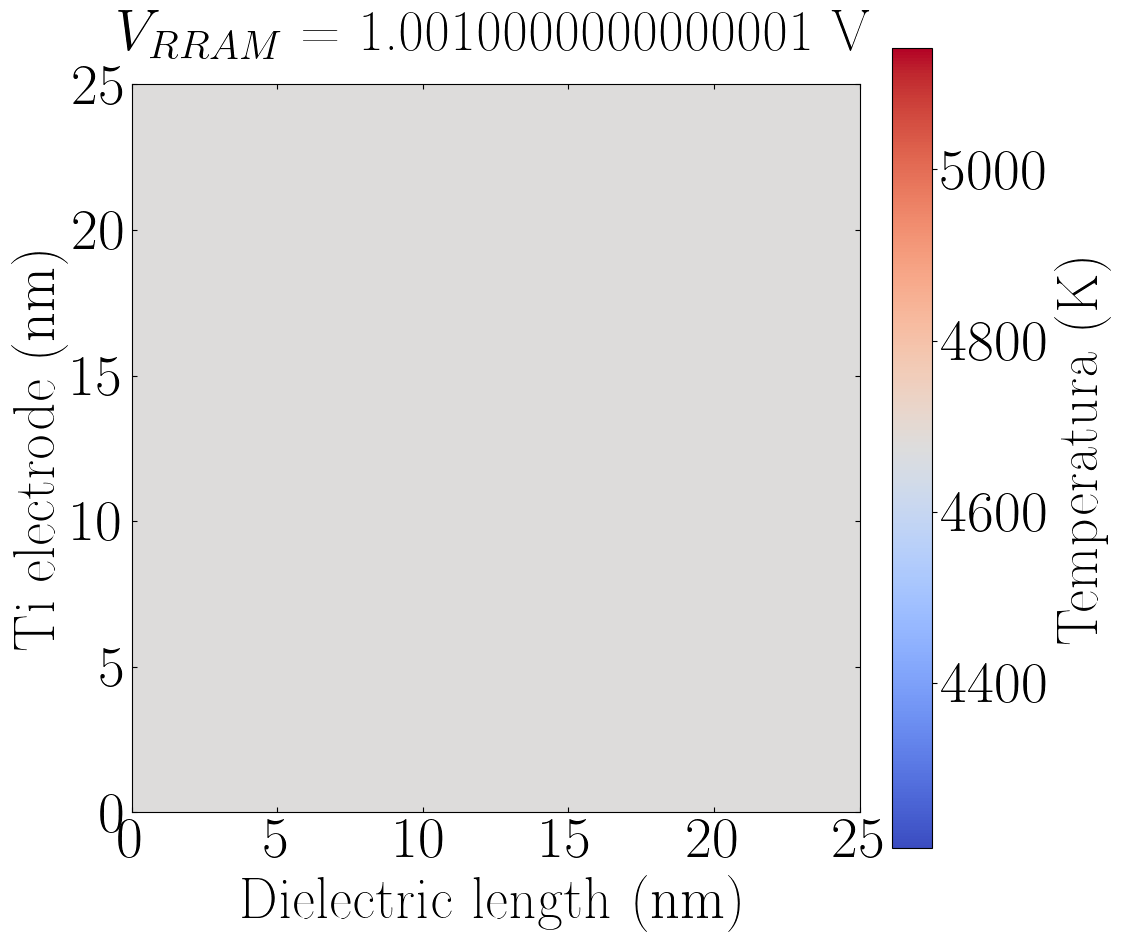

In [9]:
# Dentro de un bucle, hago el plot de para una simulación, distintos estados de la matriz de temperatura, y guardo cada imagen con un nombre que el paso
num_simulation = 9
etapa = "pp_set"

for paso in range(6300, 9100, 100):
    
    filename_temp = f"temperatura_{paso}_{etapa}.npy"
    print(f"Cargando matriz de temperatura para la simulación {num_simulation}, paso {paso}...")
    print(f"Ruta del archivo: {base_path}simulation_{num_simulation}/Figures/{filename_temp}")
    
    matriz_temp = np.load(f"{base_path}simulation_{num_simulation}/Figures/{filename_temp}")
    voltage = num_paso * 0.00011
    plot_thermal_state(
        T_map=matriz_temp,
        voltage=voltage,
        device_size=25e-9,
        save_path=f"{base_path}Thermal_State_V_{paso}.png",
    )